# Loading the data and all imports

In [70]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split


from sklearn.linear_model import LinearRegression

In [71]:
df = pd.read_csv("../data/kalshi_w_macro_markets.csv", index_col = 0)
df.head()

,Close,High,Low,Open,Volume,Day Change %,Overnight Change %,3m_treasury,2yr_treasury,10yr_treasury,...,Overnight_Volatility,Futures_Last_Price,exp_rate,exp_rate_open_interest,volume_C25,volume_H0,volume_H25,mean_C25,mean_H0,mean_H25
Date,,,,,,,,,,,,,,,,,,,,,
2025-07-31,6339.390137,6427.020020,6327.640137,6427.020020,6077080000,-1.363461,1.007718,4.41,3.94,4.37,...,0.002083,6456.75,-1.0,0.102547,20090.0,75482.0,93.0,-1.0,-1.0,-1.0
2025-08-01,6238.009766,6287.279785,6212.689941,6287.279785,5827150000,-0.783646,-0.822009,4.35,3.69,4.23,...,0.002764,6314.75,-1.0,-1.000000,17523.0,36365.0,2101.0,-1.0,-1.0,-1.0
2025-08-04,6329.939941,6330.689941,6271.709961,6271.709961,4842580000,0.928455,0.540240,4.35,3.69,4.22,...,0.000658,6304.00,-1.0,-1.000000,137586.0,192290.0,11288.0,-1.0,-1.0,-1.0
2025-08-05,6299.189941,6346.000000,6289.370117,6336.629883,5517410000,-0.590849,0.105687,4.34,3.72,4.22,...,0.001891,6365.75,-1.0,0.078286,70086.0,67412.0,108.0,-1.0,-1.0,-1.0
2025-08-06,6345.060059,6352.830078,6301.109863,6309.299805,5408560000,0.566786,0.160495,4.32,3.69,4.22,...,0.001797,6340.25,-1.0,0.021213,27087.0,32074.0,100.0,-1.0,-1.0,-1.0


In [72]:
df.head()

,Close,High,Low,Open,Volume,Day Change %,Overnight Change %,3m_treasury,2yr_treasury,10yr_treasury,...,Overnight_Volatility,Futures_Last_Price,exp_rate,exp_rate_open_interest,volume_C25,volume_H0,volume_H25,mean_C25,mean_H0,mean_H25
Date,,,,,,,,,,,,,,,,,,,,,
2025-07-31,6339.390137,6427.020020,6327.640137,6427.020020,6077080000,-1.363461,1.007718,4.41,3.94,4.37,...,0.002083,6456.75,-1.0,0.102547,20090.0,75482.0,93.0,-1.0,-1.0,-1.0
2025-08-01,6238.009766,6287.279785,6212.689941,6287.279785,5827150000,-0.783646,-0.822009,4.35,3.69,4.23,...,0.002764,6314.75,-1.0,-1.000000,17523.0,36365.0,2101.0,-1.0,-1.0,-1.0
2025-08-04,6329.939941,6330.689941,6271.709961,6271.709961,4842580000,0.928455,0.540240,4.35,3.69,4.22,...,0.000658,6304.00,-1.0,-1.000000,137586.0,192290.0,11288.0,-1.0,-1.0,-1.0
2025-08-05,6299.189941,6346.000000,6289.370117,6336.629883,5517410000,-0.590849,0.105687,4.34,3.72,4.22,...,0.001891,6365.75,-1.0,0.078286,70086.0,67412.0,108.0,-1.0,-1.0,-1.0
2025-08-06,6345.060059,6352.830078,6301.109863,6309.299805,5408560000,0.566786,0.160495,4.32,3.69,4.22,...,0.001797,6340.25,-1.0,0.021213,27087.0,32074.0,100.0,-1.0,-1.0,-1.0


In [73]:
# df = df.drop(columns=["mean_C25", "mean_H25", "exp_rate_open_interest"])
df = df.fillna(0)
df.head()

,Close,High,Low,Open,Volume,Day Change %,Overnight Change %,3m_treasury,2yr_treasury,10yr_treasury,...,Overnight_Volatility,Futures_Last_Price,exp_rate,exp_rate_open_interest,volume_C25,volume_H0,volume_H25,mean_C25,mean_H0,mean_H25
Date,,,,,,,,,,,,,,,,,,,,,
2025-07-31,6339.390137,6427.020020,6327.640137,6427.020020,6077080000,-1.363461,1.007718,4.41,3.94,4.37,...,0.002083,6456.75,-1.0,0.102547,20090.0,75482.0,93.0,-1.0,-1.0,-1.0
2025-08-01,6238.009766,6287.279785,6212.689941,6287.279785,5827150000,-0.783646,-0.822009,4.35,3.69,4.23,...,0.002764,6314.75,-1.0,-1.000000,17523.0,36365.0,2101.0,-1.0,-1.0,-1.0
2025-08-04,6329.939941,6330.689941,6271.709961,6271.709961,4842580000,0.928455,0.540240,4.35,3.69,4.22,...,0.000658,6304.00,-1.0,-1.000000,137586.0,192290.0,11288.0,-1.0,-1.0,-1.0
2025-08-05,6299.189941,6346.000000,6289.370117,6336.629883,5517410000,-0.590849,0.105687,4.34,3.72,4.22,...,0.001891,6365.75,-1.0,0.078286,70086.0,67412.0,108.0,-1.0,-1.0,-1.0
2025-08-06,6345.060059,6352.830078,6301.109863,6309.299805,5408560000,0.566786,0.160495,4.32,3.69,4.22,...,0.001797,6340.25,-1.0,0.021213,27087.0,32074.0,100.0,-1.0,-1.0,-1.0


In [74]:
target_col = "Overnight Change %"

X = df.drop(columns=[target_col])
y = df[target_col]

print(X.shape)
print(y.shape)

(153, 23)
(153,)


In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Baseline Linear Regression Model

In [76]:
linear_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("regressor", LinearRegression()),
    ]
)
linear_model.fit(X_train, y_train)

y_hat_train = linear_model.predict(X_train)
y_hat_test = linear_model.predict(X_test)

train_mse = mean_squared_error(y_train, y_hat_train)
test_mse = mean_squared_error(y_test, y_hat_test)

print("Linear Regression")
print("train_mse:", train_mse)
print("test_mse:", test_mse)

Linear Regression
train_mse: 0.08963633606522899
test_mse: 0.13800259482215207


inspect the coefficients and the actual v. predicted 

In [77]:
coef_df = pd.DataFrame(
    {
        "feature": X.columns,
        "coefficient": linear_model.named_steps["regressor"].coef_,
    }
)
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)
coef_df.head(15)


,feature,coefficient,abs_coefficient
0,Close,-3.305892,3.305892
3,Open,1.559894,1.559894
1,High,1.347737,1.347737
2,Low,0.533768,0.533768
5,Day Change %,0.491185,0.491185
12,Overnight_Return,0.218097,0.218097
14,Futures_Last_Price,-0.176732,0.176732
10,VIX,-0.170127,0.170127
11,fed_funds_rate,0.120049,0.120049
6,3m_treasury,-0.067359,0.067359


actual v predicted preview 

In [78]:
results_preview = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_hat_test
})

results_preview.head(15)

,Actual,Predicted
Date,,
2025-11-28,0.145468,0.310914
2025-12-02,0.269060,0.153040
2025-12-17,0.038530,0.362032
2026-01-14,-0.378103,-0.302344
2025-09-11,0.342468,0.219894
2026-01-13,0.002008,0.279408
2025-11-19,0.128753,-0.289743
2025-11-24,0.508100,-0.040603
2025-08-26,-0.059472,0.131144


# Lasso Model

In [79]:
from sklearn.linear_model import LassoCV

lasso_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LassoCV(cv=5, random_state=42)),
    ]
)
lasso_model.fit(X_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.003702082709546417, tolerance: 0.0018950494886832417
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.010712405743083409, tolerance: 0.0018950494886832417
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.02012069395901328, tolerance: 0.0018950494886832417
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coord

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LassoCV(cv=5, random_state=42))])

In [80]:
y_hat_train_lasso = lasso_model.predict(X_train)
y_hat_test_lasso = lasso_model.predict(X_test)

lasso_train_mse = mean_squared_error(y_train, y_hat_train_lasso)
lasso_test_mse = mean_squared_error(y_test, y_hat_test_lasso)

print("Lasso Regression")
print("train_mse:", lasso_train_mse)
print("test_mse:", lasso_test_mse)


Lasso Regression
train_mse: 0.12024897726728254
test_mse: 0.10883702870319638


In [81]:
lasso_coef_df = pd.DataFrame(
    {
        "feature": X.columns,
        "coefficient": lasso_model.named_steps["model"].coef_,
    }
)

lasso_coef_df["abs_coefficient"] = lasso_coef_df["coefficient"].abs()
lasso_coef_df = lasso_coef_df.sort_values("abs_coefficient", ascending=False)

lasso_coef_df.head(20)

,feature,coefficient,abs_coefficient
12,Overnight_Return,0.180419,0.180419
10,VIX,-0.022291,0.022291
0,Close,-0.000000,0.000000
21,mean_H0,-0.000000,0.000000
20,mean_C25,-0.000000,0.000000
19,volume_H25,0.000000,0.000000
18,volume_H0,0.000000,0.000000
17,volume_C25,0.000000,0.000000
16,exp_rate_open_interest,-0.000000,0.000000
15,exp_rate,-0.000000,0.000000


In [82]:
num_kept = (lasso_coef_df["coefficient"] != 0).sum()
num_dropped = (lasso_coef_df["coefficient"] == 0).sum()

print("Number of predictors kept by Lasso:", num_kept)
print("Number of predictors dropped by Lasso:", num_dropped)
print("Predictors dropped by Lasso:", lasso_coef_df[lasso_coef_df["coefficient"] == 0]["feature"].tolist())

Number of predictors kept by Lasso: 2
Number of predictors dropped by Lasso: 21
Predictors dropped by Lasso: ['Close', 'mean_H0', 'mean_C25', 'volume_H25', 'volume_H0', 'volume_C25', 'exp_rate_open_interest', 'exp_rate', 'Futures_Last_Price', 'Overnight_Volatility', 'fed_funds_rate', 'High', 'yield_curve', '10yr_treasury', '2yr_treasury', '3m_treasury', 'Day Change %', 'Volume', 'Open', 'Low', 'mean_H25']


quick comparison of 2 models

In [83]:
comparison_df = pd.DataFrame(
    {
        "model": ["Linear Regression", "Lasso"],
        "train_mse": [train_mse, lasso_train_mse],
        "test_mse": [test_mse, lasso_test_mse],
    }   
)

comparison_df

,model,train_mse,test_mse
0,Linear Regression,0.089636,0.138003
1,Lasso,0.120249,0.108837


# Ridge Model

In [84]:
from sklearn.linear_model import RidgeCV

ridge_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", RidgeCV(cv=5)),
    ]
)
ridge_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', RidgeCV(cv=5))])

In [85]:
y_hat_train_ridge = ridge_model.predict(X_train)
y_hat_test_ridge = ridge_model.predict(X_test)

ridge_train_mse = mean_squared_error(y_train, y_hat_train_ridge)
ridge_test_mse = mean_squared_error(y_test, y_hat_test_ridge)

print("Ridge Regression")
print("train_mse:", ridge_train_mse)
print("test_mse:", ridge_test_mse)

Ridge Regression
train_mse: 0.1008506395247304
test_mse: 0.13794799079038791


In [86]:
ridge_coef_df = pd.DataFrame(
    {
        "feature": X.columns,
        "coefficient": ridge_model.named_steps["model"].coef_,
    }
)
ridge_coef_df["abs_coefficient"] = ridge_coef_df["coefficient"].abs()
ridge_coef_df = ridge_coef_df.sort_values("abs_coefficient", ascending=False)
ridge_coef_df.head(20)

,feature,coefficient,abs_coefficient
12,Overnight_Return,0.203443,0.203443
10,VIX,-0.109856,0.109856
5,Day Change %,-0.068182,0.068182
1,High,0.061216,0.061216
21,mean_H0,-0.049505,0.049505
15,exp_rate,-0.040706,0.040706
20,mean_C25,0.038778,0.038778
14,Futures_Last_Price,-0.037303,0.037303
17,volume_C25,0.037198,0.037198
18,volume_H0,-0.029705,0.029705


comparison

In [87]:
comparison_df = pd.DataFrame(
    {
        "model": ["Linear Regression", "Lasso", "Ridge"],
        "train_mse": [train_mse, lasso_train_mse, ridge_train_mse],
        "test_mse": [test_mse, lasso_test_mse, ridge_test_mse],
    }
)
comparison_df

,model,train_mse,test_mse
0,Linear Regression,0.089636,0.138003
1,Lasso,0.120249,0.108837
2,Ridge,0.100851,0.137948


# Elastic Net Model

In [88]:
from sklearn.linear_model import ElasticNetCV

elastic_net_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", ElasticNetCV(cv=5, random_state=42)),
    ]
)
elastic_net_model.fit(X_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0019411042954882163, tolerance: 0.0018950494886832417
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.002178785787029014, tolerance: 0.0018950494886832417
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0024446797541379794, tolerance: 0.0018950494886832417
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_co

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', ElasticNetCV(cv=5, random_state=42))])

In [89]:
y_hat_train_elastic = elastic_net_model.predict(X_train)
y_hat_test_elastic = elastic_net_model.predict(X_test)

elastic_train_mse = mean_squared_error(y_train, y_hat_train_elastic)
elastic_test_mse = mean_squared_error(y_test, y_hat_test_elastic)
print("Elastic Net Regression")
print("train_mse:", elastic_train_mse)
print("test_mse:", elastic_test_mse)

Elastic Net Regression
train_mse: 0.1203674031207396
test_mse: 0.10898575713114689


In [90]:
elastic_coef_df = pd.DataFrame(
    {
        "feature": X.columns,
        "coefficient": elastic_net_model.named_steps["model"].coef_,
    }
)
elastic_coef_df["abs_coefficient"] = elastic_coef_df["coefficient"].abs()
elastic_coef_df = elastic_coef_df.sort_values("abs_coefficient", ascending=False)
elastic_coef_df.head(20)

,feature,coefficient,abs_coefficient
12,Overnight_Return,0.173595,0.173595
10,VIX,-0.025906,0.025906
11,fed_funds_rate,0.002749,0.002749
21,mean_H0,-0.000000,0.000000
20,mean_C25,-0.000000,0.000000
19,volume_H25,0.000000,0.000000
18,volume_H0,0.000000,0.000000
17,volume_C25,0.000000,0.000000
16,exp_rate_open_interest,-0.000000,0.000000
15,exp_rate,-0.000000,0.000000


In [91]:
elastic_nonzero = elastic_coef_df[elastic_coef_df["coefficient"] != 0].copy()
elastic_nonzero.head(20)

,feature,coefficient,abs_coefficient
12,Overnight_Return,0.173595,0.173595
10,VIX,-0.025906,0.025906
11,fed_funds_rate,0.002749,0.002749


compare 4 models so far 

In [92]:
comparison_df = pd.DataFrame(
    {
        "model": ["Linear Regression", "Lasso", "Ridge", "Elastic Net"],
        "train_mse": [train_mse, lasso_train_mse, ridge_train_mse, elastic_train_mse],
        "test_mse": [test_mse, lasso_test_mse, ridge_test_mse, elastic_test_mse],
    }
)
comparison_df

,model,train_mse,test_mse
0,Linear Regression,0.089636,0.138003
1,Lasso,0.120249,0.108837
2,Ridge,0.100851,0.137948
3,Elastic Net,0.120367,0.108986


# Random Forest

In [93]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline(
    [
        ("model", RandomForestRegressor(n_estimators=100, random_state=42)),
    ]
)
random_forest_model.fit(X_train, y_train)   

Pipeline(steps=[('model', RandomForestRegressor(random_state=42))])

In [94]:
y_hat_train_random_forest = random_forest_model.predict(X_train)
y_hat_test_random_forest = random_forest_model.predict(X_test)

random_forest_train_mse = mean_squared_error(y_train, y_hat_train_random_forest)
random_forest_test_mse = mean_squared_error(y_test, y_hat_test_random_forest)

print("Random Forest Regression")
print("train_mse:", random_forest_train_mse)
print("test_mse:", random_forest_test_mse)

Random Forest Regression
train_mse: 0.020429378437097395
test_mse: 0.12169210632766538


In [95]:
random_forest_importance_df = pd.DataFrame(
    {
        "feature": X.columns,
        "importance": random_forest_model.named_steps["model"].feature_importances_,
    }
)
random_forest_importance_df = random_forest_importance_df.sort_values("importance", ascending=False)
random_forest_importance_df.head(20)

,feature,importance
12,Overnight_Return,0.455644
5,Day Change %,0.070756
10,VIX,0.069387
18,volume_H0,0.036720
19,volume_H25,0.036288
13,Overnight_Volatility,0.035881
4,Volume,0.032139
21,mean_H0,0.030450
20,mean_C25,0.029940
15,exp_rate,0.029532


plot feauture imprtance

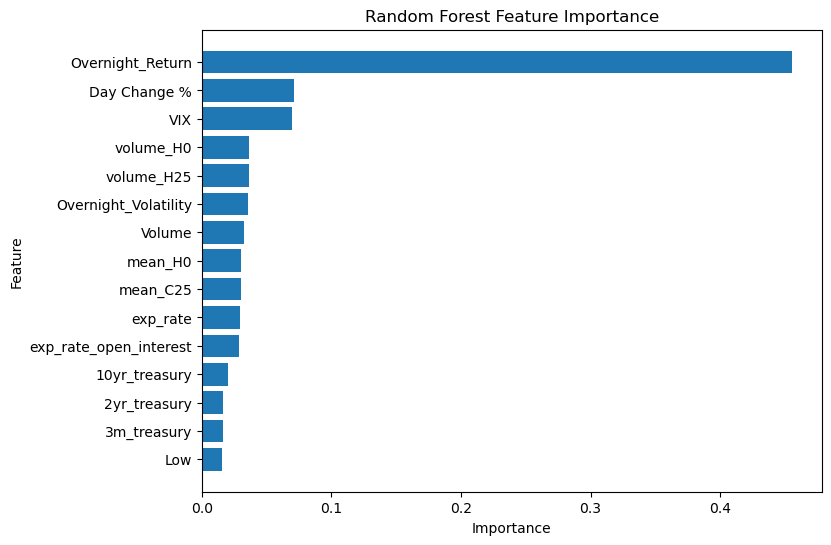

In [96]:
import matplotlib.pyplot as plt

top_n = 15
plot_df = random_forest_importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# Comparing all 5 models 

In [97]:
comparison_df = pd.DataFrame(
    {
        "model": ["Linear Regression", "Lasso", "Ridge", "Elastic Net", "Random Forest"],
        "train_mse": [train_mse, lasso_train_mse, ridge_train_mse, elastic_train_mse, random_forest_train_mse],
        "test_mse": [test_mse, lasso_test_mse, ridge_test_mse, elastic_test_mse, random_forest_test_mse],
    }
)
print(comparison_df)
comparison_df.to_csv("model_comparison.csv", index=False)

               model  train_mse  test_mse
0  Linear Regression   0.089636  0.138003
1              Lasso   0.120249  0.108837
2              Ridge   0.100851  0.137948
3        Elastic Net   0.120367  0.108986
4      Random Forest   0.020429  0.121692


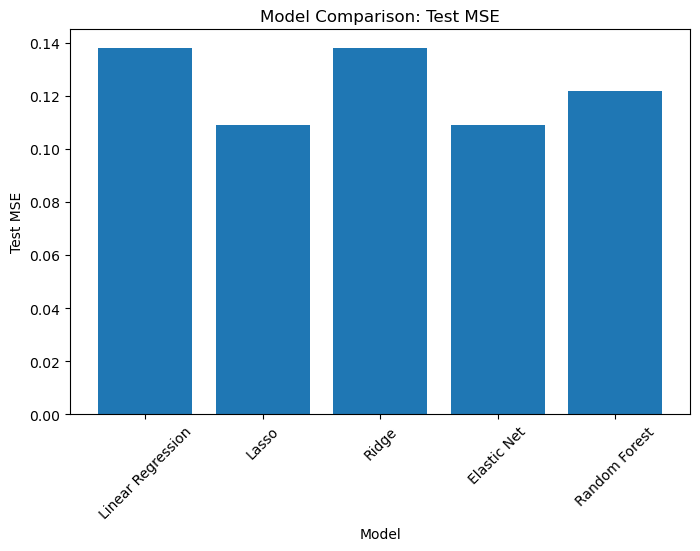

In [98]:
import matplotlib.pyplot as plt

results_plot = comparison_df[["model", "test_mse"]].copy()

plt.figure(figsize=(8, 5))
plt.bar(results_plot["model"], results_plot["test_mse"])
plt.xlabel("Model")
plt.ylabel("Test MSE")
plt.title("Model Comparison: Test MSE")
plt.xticks(rotation=45)
plt.show()